In [4]:
# Importando a biblioteca de manipulação de dados
import pandas as pd

# 1. Carregando os dados brutos
caminho_arquivo = '../data/BankChurners.csv'
df = pd.read_csv(caminho_arquivo)

# Exibindo as primeiras 5 linhas para entender o que temos
display(df.head())

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [6]:
# 1. Removendo as duas últimas colunas inúteis do Kaggle (geradas por um modelo prévio)
df = df.iloc[:, :-2]

# 2. Padronizando os nomes das colunas (tudo minúsculo e sem espaços)
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

# 3. Renomeando algumas colunas específicas para o português, focando na visão de negócio
df = df.rename(columns={
    'clientnum': 'id_cliente',
    'attrition_flag': 'status_cliente',
    'customer_age': 'idade',
    'gender': 'genero',
    'dependent_count': 'dependentes',
    'education_level': 'escolaridade',
    'marital_status': 'estado_civil',
    'income_category': 'faixa_renda',
    'card_category': 'categoria_cartao',
    'months_on_book': 'meses_relacionamento',
    'credit_limit': 'limite_credito',
    'total_trans_amt': 'valor_total_transacoes',
    'total_trans_ct': 'qtd_total_transacoes'
})

# Verificando a qualidade: há valores nulos (dados vazios) que precisamos tratar?
print("Valores nulos no dataset:\n", df.isnull().sum())

# Salvando o dado limpo e tratado
df.to_csv('../data/dataset_credito_limpo.csv', index=False)

print("\n Limpeza concluída! Arquivo 'dataset_credito_limpo.csv' salvo com sucesso.")

Valores nulos no dataset:
 id_cliente                  0
status_cliente              0
idade                       0
genero                      0
dependentes                 0
escolaridade                0
estado_civil                0
faixa_renda                 0
categoria_cartao            0
meses_relacionamento        0
total_relationship_count    0
months_inactive_12_mon      0
contacts_count_12_mon       0
limite_credito              0
total_revolving_bal         0
avg_open_to_buy             0
total_amt_chng_q4_q1        0
valor_total_transacoes      0
qtd_total_transacoes        0
dtype: int64

 Limpeza concluída! Arquivo 'dataset_credito_limpo.csv' salvo com sucesso.


C:\Users\Larissa Góis\AppData\Local\Temp\ipykernel_13476\2133857074.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='status_cliente', palette='Set2')


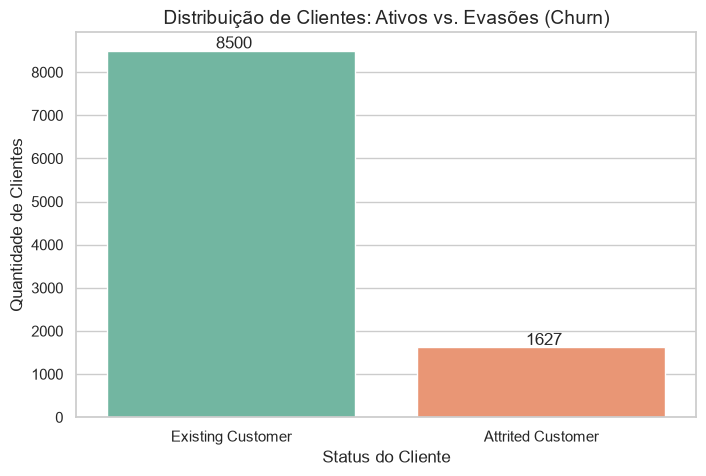

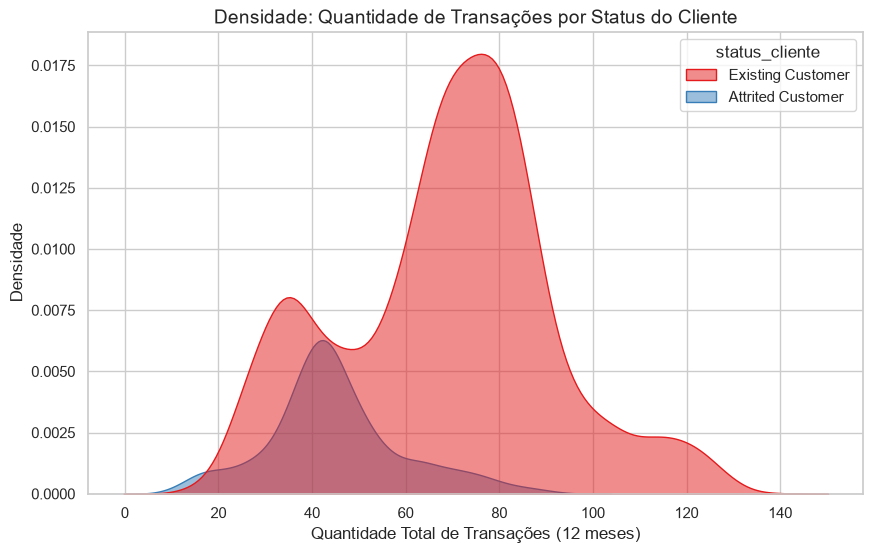

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para um visual mais "limpo" e corporativo
sns.set_theme(style="whitegrid")

# 1. Qual é a nossa Taxa de Churn atual? (A dor do negócio)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='status_cliente', palette='Set2')
plt.title('Distribuição de Clientes: Ativos vs. Evasões (Churn)', fontsize=14)
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Status do Cliente')

# Adicionando os números exatos em cima das barras para facilitar a leitura
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))
plt.show()

# 2. Comportamento: Quem cancela o cartão usa menos?
# Vamos cruzar o Status com a Quantidade de Transações nos últimos 12 meses
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='qtd_total_transacoes', hue='status_cliente', fill=True, palette='Set1', alpha=0.5)
plt.title('Densidade: Quantidade de Transações por Status do Cliente', fontsize=14)
plt.xlabel('Quantidade Total de Transações (12 meses)')
plt.ylabel('Densidade')
plt.show()